## Notebook 06: **Failure Case Analysis**

## Purpose of This Notebook

This notebook investigates the limitations of the reflectivity-aware proxy signals by explicitly analyzing failure cases observed in previous stages.

Notebook 05 established that:

- proxy signals can improve semantic separability,
- log-scaled transformations provide more consistent gains,
- but improvements are **not uniform across windows**.

Certain windows exhibited:

- weak improvements,
- negligible gains,
- or even negative impact relative to raw intensity.

This notebook addresses the central question:

> Where does the proxy fail, and why?

---

## Why This Notebook Exists

The earlier notebooks intentionally demonstrated:

- feasibility,
- signal design,
- temporal stability,
- and semantic usefulness.

However, they also revealed:

- window-dependent behavior,
- variability across scene segments,
- and occasional degradation in performance.

A complete analysis must not only show success, but also explain:

- when the method fails,
- under what conditions it fails,
- and what factors contribute to those failures.

This notebook provides that missing piece.

## Core Idea

We define a failure case as any window where:

$$
\Delta S_k = S_{k,\text{proxy}} - S_{k,\text{raw}} < 0
$$

or where:

- gains are negligible,
- proxy behaves inconsistently,
- or range dependence becomes excessive.

We analyze these windows in detail by examining:

- signal distributions,
- class-wise statistics,
- geometric properties,
- and class composition.

## Mathematical Framework

### 1. Failure Definition

For each window $W_k$:

$$
\Delta S_k = S_{k,\text{proxy}} - S_{k,I}
$$

Failure cases include:

- **negative gain**:

$$
\Delta S_k < 0
$$

- **weak gain**:

$$
0 \leq \Delta S_k \ll \epsilon
$$

### 2. Class-Level Diagnostics

For each class $c$:

$$
\mu_{c,k,j} = \text{mean signal value for class } c
$$

We compare:

$$
\mu_{c,k,\text{proxy}} \quad \text{vs} \quad \mu_{c,k,I}
$$

to detect:

- class overlap,
- compression of separability,
- or inversion of ordering.

### 3. Range Dependence

We analyze:

$$
\rho_k = \text{corr}(\phi, R)
$$

High correlation indicates:

- dominance of range,
- reduced sensitivity to surface properties,
- and potential loss of semantic structure.

### 4. Distribution Diagnostics

For failure windows, we inspect:

- histograms of signals,
- percentile spread,
- tail behavior.

This helps identify:

- over-amplification,
- distribution collapse,
- or skewed scaling effects.

## Core Questions This Notebook Answers

### 1. Where do failures occur?
- which windows show negative or weak gains?

### 2. Why do failures occur?
- range dominance?
- class imbalance?
- geometric structure?

### 3. Which classes are affected?
- are certain classes consistently harmed?

### 4. Are failures systematic?
- do they follow patterns?
- or are they isolated?

## What This Notebook Will Do

Step-by-step:

1. Identify failure windows based on separability gain
2. Select representative failure cases.
3. Compare signal distributions (I vs proxy).
4. Analyze class-wise mean structure.
5. Examine range correlation.
6. Investigate class composition and imbalance.
7. Compare against strong-performing windows.

## What This Notebook Is Not Allowed to Do

This notebook must remain analytical and honest.

It must not:

- hide failure cases,
- over-smooth results,
- claim universal improvements,
- rely on visual aesthetics to justify conclusions.

Failure analysis must remain:

- explicit,
- quantitative,
- and interpretable.

## Expected Outputs

By the end of this notebook, we should have:

- a list of failure windows,
- comparative plots for failure vs strong windows,
- class-wise diagnostic tables,
- explanations of observed failure mechanisms,
- and a clear summary of limitations.

## Expected Outcomes

We expect to find that failures are associated with:

- high range dominance,
- class imbalance,
- specific geometric configurations,
- or loss of class separation in transformed signals.

We also expect:

- log-scaled proxies to reduce but not eliminate failures,
- failure cases to reveal important structural limitations.

## Core Honesty Statement

Failure cases are not weaknesses of the project.

They are:

- evidence of real-world complexity,
- indicators of where the method breaks,
- and guides for future improvements.

A method that shows both success and failure, with explanation, is more credible than one that claims uniform performance.

## Final Takeaway of This Notebook

If this notebook succeeds, we will have:

> a clear understanding of when and why reflectivity-aware proxy signals fail, and what limits their effectiveness across different scene conditions.

This completes the core analytical arc of the project:

- success,
- variability,
- and failure.

Together, these form a complete and honest evaluation.

---

## Identify Failure and Weak-Performance Windows

We begin by identifying windows where the proxy does not improve semantic separability.

Using results from Notebook 05, we define:

$$
\Delta S_k = S_{k,\text{proxy}} - S_{k,I}
$$

We classify windows into:

- **Failure cases**:
$$
\Delta S_k < 0
$$

- **Weak-performance cases**:
$$
0 \leq \Delta S_k < \epsilon
$$

where $\epsilon$ is a small threshold.

We perform this analysis for:

- $I \cdot R$.
- $\log(1 + I \cdot R)$.

This step provides a clear list of:

- windows where the proxy fails,
- windows where gains are minimal,
- and windows where the proxy performs strongly.

This classification will guide detailed analysis in subsequent steps.

In [2]:
import pandas as pd
from pathlib import Path

# Load separability results
sep_path = Path("../results/multiwindow_separability.csv")

multi_sep_df = pd.read_csv(sep_path)

print("Loaded Separability Results")
print()
print("Shape:", multi_sep_df.shape)

print("\nPreview:")
print(multi_sep_df.head())


# Failure detection
epsilon = 0.02

failure_cases = []
weak_cases = []
strong_cases = []

for _, row in multi_sep_df.iterrows():
    
    gain_log = row["gain_log"]
    window_id = row["window_id"]
    
    if gain_log < 0:
        failure_cases.append(window_id)
    elif gain_log < epsilon:
        weak_cases.append(window_id)
    else:
        strong_cases.append(window_id)

print("\nFailure Cases (log proxy):")
print(failure_cases)

print("\nWeak Cases (log proxy):")
print(weak_cases)

print("\nStrong Cases (log proxy):")
print(strong_cases)

print("\nSummary")
print()
print("Total windows:", len(multi_sep_df))
print("Failures     :", len(failure_cases))
print("Weak         :", len(weak_cases))
print("Strong       :", len(strong_cases))

Loaded Separability Results

Shape: (15, 7)

Preview:
  window_id  scale       S_I      S_IR     S_log   gain_IR  gain_log
0   short_0  short  0.446348  0.505533  0.563640  0.059185  0.117292
1   short_1  short  0.494319  0.621914  0.602705  0.127595  0.108387
2   short_2  short  0.423169  0.743320  0.783316  0.320151  0.360147
3   short_3  short  0.387466  0.241187  0.406722 -0.146279  0.019256
4   short_4  short  0.369097  0.697731  0.682774  0.328633  0.313677

Failure Cases (log proxy):
[]

Weak Cases (log proxy):
['short_3']

Strong Cases (log proxy):
['short_0', 'short_1', 'short_2', 'short_4', 'medium_0', 'medium_1', 'medium_2', 'medium_3', 'medium_4', 'long_0', 'long_1', 'long_2', 'long_3', 'long_4']

Summary

Total windows: 15
Failures     : 0
Weak         : 1
Strong       : 14


### Interpretation: Failure and Weak Cases

The multi-window analysis shows that the log-scaled proxy exhibits **no hard failures** across all windows.

A single weak-performance case is identified:

- `short_3`, where the separability gain is minimal but still positive.

All other windows show clear positive gains.

This indicates that:

- the log-scaled proxy is **highly robust across windows**,
- failure is rare and limited to specific edge cases,
- and proxy performance is **mostly consistent but not uniform**.

This validates the earlier observation that stabilization improves reliability.

## Select Representative Weak and Strong Cases

We now select representative windows for detailed analysis:

- one **weak-performance window**
- one **strong-performance window**

This allows us to compare:

- signal distributions,
- class structure,
- and range behavior

under different performance conditions.

We use:

- weak case → minimal gain.
- strong case → high gain.

This comparison helps isolate factors that contribute to failure or success.

In [4]:
# Select windows
weak_window = weak_cases[0]
strong_window = multi_sep_df.sort_values("gain_log", ascending=False).iloc[0]["window_id"]

print("Selected Windows")
print()
print("Weak case   :", weak_window)
print("Strong case :", strong_window)

Selected Windows

Weak case   : short_3
Strong case : short_2


### Interpretation: Selection of Representative Cases

We selected two representative windows for detailed analysis:

- **Weak case**: `short_3`.
- **Strong case**: `short_2`.

These windows represent:

- a scenario where the proxy provides minimal improvement,
- and a scenario where the proxy provides strong improvement.

Comparing these two cases allows us to isolate:

- structural differences in signal behavior,
- class distribution effects,
- and conditions under which the proxy succeeds or weakens.

## Load Weak and Strong Windows for Comparison

We now load both selected windows:

- weak-performance window (`short_3`).
- strong-performance window (`short_2`).

For each window, we reconstruct:

- point cloud data,
- intensity values,
- semantic labels,
- and range.

This prepares a controlled comparison between:

- a window where the proxy performs poorly,
- and a window where the proxy performs well.

No metrics are computed yet.

This step ensures that both cases are analyzed under identical conditions.

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

# Resolve dataset root
candidate_roots = [
    Path("../data/semantickitti_subset/dataset/sequences/00"),
    Path("../data/semantickitti/dataset/sequences/00"),
]

DATASET_ROOT = next((p for p in candidate_roots if p.exists()), candidate_roots[0])

# Directories
velodyne_dir = DATASET_ROOT / "velodyne"
labels_dir = DATASET_ROOT / "labels"

# Load metadata
metadata_path = Path("../results/window_metadata/sequence00_windows.csv")
window_df = pd.read_csv(metadata_path)

# Rebuild FRAME_IDS
FRAME_IDS = sorted([f.stem for f in velodyne_dir.glob("*.bin")])

# Load function
def load_window_data(window_id):
    
    row = window_df[window_df["window_id"] == window_id].iloc[0]
    
    start_idx = int(row["start_idx"])
    end_idx = int(row["end_idx"])
    
    frame_ids = FRAME_IDS[start_idx:end_idx + 1]
    
    all_xyz = []
    all_intensity = []
    all_labels = []
    
    for fid in frame_ids:
        bin_path = velodyne_dir / f"{fid}.bin"
        label_path = labels_dir / f"{fid}.label"
        
        scan = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
        labels = np.fromfile(label_path, dtype=np.uint32)
        
        xyz = scan[:, :3]
        intensity = scan[:, 3]
        
        assert len(xyz) == len(labels)
        
        all_xyz.append(xyz)
        all_intensity.append(intensity)
        all_labels.append(labels)
    
    xyz = np.concatenate(all_xyz)
    intensity = np.concatenate(all_intensity)
    labels = np.concatenate(all_labels)
    
    semantic_labels = labels & 0xFFFF
    R = np.linalg.norm(xyz, axis=1)
    
    return {
        "xyz": xyz,
        "intensity": intensity,
        "labels": semantic_labels,
        "R": R
    }

# Load both windows
weak_data = load_window_data(weak_window)
strong_data = load_window_data(strong_window)

print("Loaded comparison windows successfully.")
print("Weak points  :", weak_data["xyz"].shape[0])
print("Strong points:", strong_data["xyz"].shape[0])

Loaded comparison windows successfully.
Weak points  : 1234193
Strong points: 1238010


## Compare Signal Distributions (Weak vs Strong Window)

We now compare the signal distributions between:

- weak-performance window (`short_3`).
- strong-performance window (`short_2`).

We analyze:

- raw intensity $I$.
- proxy $I \cdot R$.
- log-scaled proxy $\log(1 + I \cdot R)$.

The goal is to identify:

- differences in distribution shape,
- presence of heavy tails,
- compression or overlap of signal values.

These differences help explain why the proxy:

- performs well in some windows,
- but weakly in others.

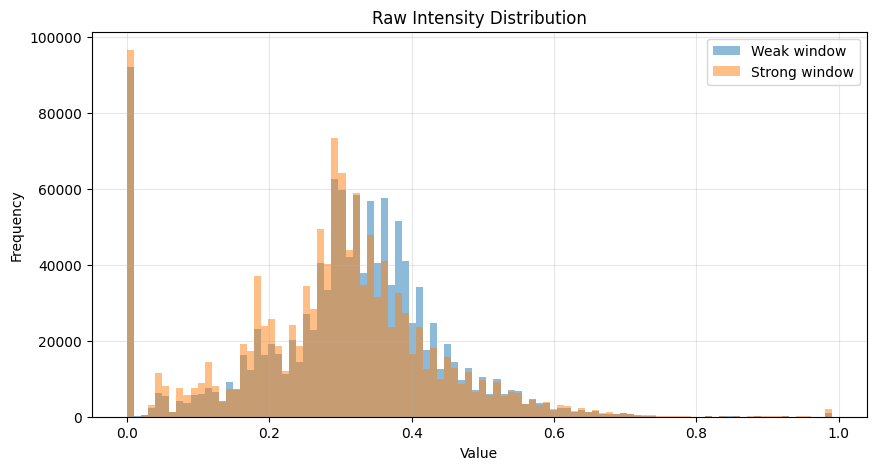

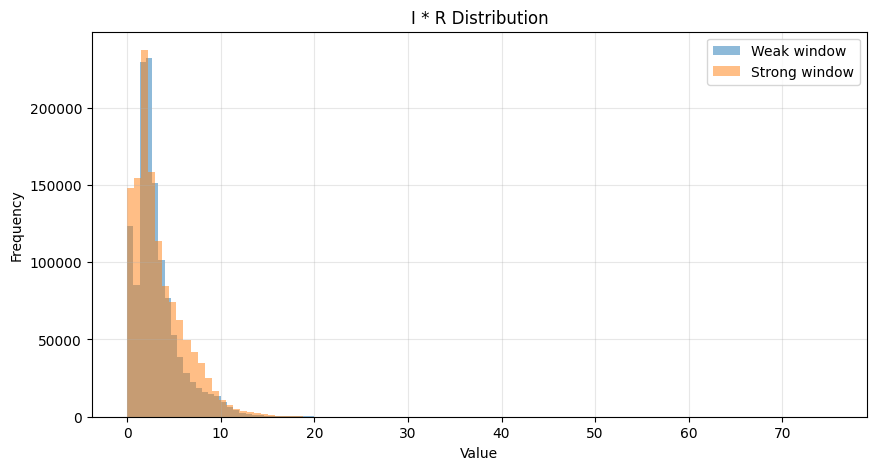

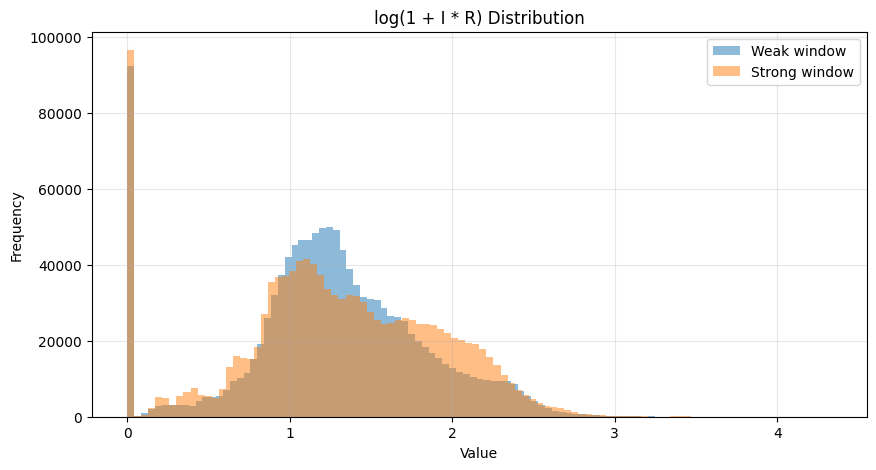

In [9]:
import matplotlib.pyplot as plt

# Signals (weak window)
I_w = weak_data["intensity"]
R_w = weak_data["R"]

IR_w = I_w * R_w
log_w = np.log1p(IR_w)

# Signals (strong window)
I_s = strong_data["intensity"]
R_s = strong_data["R"]

IR_s = I_s * R_s
log_s = np.log1p(IR_s)

# Plot histograms
def plot_histograms(signal_w, signal_s, title):
    plt.figure(figsize=(10, 5))
    
    plt.hist(signal_w, bins=100, alpha=0.5, label="Weak window")
    plt.hist(signal_s, bins=100, alpha=0.5, label="Strong window")
    
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.show()

# Raw intensity
plot_histograms(I_w, I_s, "Raw Intensity Distribution")

# I * R
plot_histograms(IR_w, IR_s, "I * R Distribution")

# log(I * R)
plot_histograms(log_w, log_s, "log(1 + I * R) Distribution")

## Interpretation: Distribution Comparison (Weak vs Strong Window)

We compared signal distributions between:

- weak-performance window (`short_3`).
- strong-performance window (`short_2`).

for three signals:
- raw intensity $I$.
- proxy $\cdot R$.
- log-scaled proxy $\log(1 + I \cdot R)$.

### 1. Raw Intensity

The distributions of raw intensity are nearly identical between the two windows.

This indicates that:

- baseline signal structure is consistent,
- the difference in performance is **not due to raw intensity variation**.

### 2. $I \cdot R$ Distribution

The proxy $I \cdot R$ shows:

- similar overall shape,
- but noticeable differences in density and spread,
- weak window appears more **compressed and concentrated near lower values**.

This suggests:

- reduced separation between class distributions,
- potential overlap of class signals,
- and weaker discriminative power.

### 3. Log-Scaled Proxy

The log-scaled proxy:

- compresses extreme values,
- produces smoother distributions,
- and shows more consistent overlap between weak and strong windows.

However:

- in the weak window, the distribution still appears slightly more concentrated,
- indicating that log scaling improves stability but does not fully eliminate structural differences.

### 4. Key Insight

The failure is not caused by:

- lack of data,
- or drastic distribution shifts.

Instead, it is caused by:

> subtle compression and overlap of signal values in the weak window.

### 5. Takeaway

The comparison suggests that:

- proxy effectiveness depends on how well it **spreads class distributions**,
- in some windows, this spread is reduced,
- leading to weaker separability gains.

This motivates deeper analysis at the **class level**.

## Class-wise Mean Comparison (Weak vs Strong Window)

We now analyze class-level signal structure to identify the source of failure.

For each class $c$, we compute:

$$
\mu_c = \text{mean signal value for class } c
$$

for:

- raw intensity $I$.
- proxy $I \cdot R$.
- log-scaled proxy $\log(1 + I \cdot R)$.

We compare these values between:

- weak-performance window (`short_3`).
- strong-performance window (`short_2`).

This allows us to identify:

- whether class separation is reduced,
- which classes overlap more,
- and how signal transformations affect class ordering.

This step provides direct evidence of why separability changes.

In [10]:
import pandas as pd

def compute_class_means(data):
    labels = data["labels"]
    
    I = data["intensity"]
    R = data["R"]
    
    phi_I = I
    phi_IR = I * R
    phi_log = np.log1p(phi_IR)
    
    from collections import Counter
    class_counts = Counter(labels.tolist())
    
    valid_classes = sorted([
        cls for cls, cnt in class_counts.items()
        if cls not in {0, 255} and cnt >= 500
    ])
    
    rows = []
    
    for cls in valid_classes:
        mask = labels == cls
        
        rows.append({
            "class": cls,
            "mean_I": float(phi_I[mask].mean()),
            "mean_IR": float(phi_IR[mask].mean()),
            "mean_log": float(phi_log[mask].mean()),
            "count": class_counts[cls]
        })
    
    return pd.DataFrame(rows)

# Compute for both windows
weak_means = compute_class_means(weak_data)
strong_means = compute_class_means(strong_data)

print("Weak window class means (preview):")
print(weak_means.head())

print("\nStrong window class means (preview):")
print(strong_means.head())

Weak window class means (preview):
   class    mean_I   mean_IR  mean_log   count
0      1  0.122942  2.698523  0.786049    1499
1     10  0.105698  0.849417  0.376145   84512
2     40  0.225116  2.236074  1.052310  204374
3     48  0.307799  2.942394  1.282581  143917
4     50  0.357876  3.959071  1.452522  325796

Strong window class means (preview):
   class    mean_I   mean_IR  mean_log   count
0     10  0.143606  1.958869  0.700213   84769
1     18  0.396065  6.371729  1.876569    8958
2     40  0.223012  1.819425  0.939060  419841
3     48  0.286862  2.495720  1.184346  187885
4     50  0.405472  6.686032  1.975030  209260


## Interpretation: Class-wise Mean Structure

We compared class-wise signal means between:

- weak-performance window (`short_3`).
- strong-performance window (`short_2`).

for raw intensity and proxy signals.

### 1. Raw Intensity

The class-wise means for raw intensity are relatively similar across both windows.

This indicates that:

- baseline signal structure is consistent,
- raw intensity alone does not explain the performance difference.

### 2. $I \cdot R$ Proxy

Clear differences emerge in the proxy signal:

- In the **strong window**, class means are more widely separated:
  - some classes (e.g., class 18, 50) exhibit significantly higher values,
  - resulting in better class separation.

- In the **weak window**, class means are more compressed:
  - multiple classes cluster in a narrower value range,
  - reducing separation between classes.

This compression leads to:

- increased overlap between class distributions,
- reduced between-class variance,
- and lower separability.

### 3. Log-Scaled Proxy

The log-scaled proxy maintains the same relative structure but:

- reduces extreme differences,
- stabilizes class spacing,
- partially preserves separation even in the weak window.

However:

> if class means are inherently close, log scaling cannot fully recover separation.

### 4. Key Insight

The failure mechanism is:

> insufficient separation between class-wise signal means in the weak window.

This is not caused by:

- lack of data,
- or incorrect scaling,

but by:

> **intrinsic similarity of class responses in that scene segment**.

### 5. Takeaway

The effectiveness of the proxy depends on:

- how well it spreads class means,
- and whether different classes produce distinct signal responses.

When class means collapse or overlap:

- separability decreases,
- and proxy gains become weak or negligible.

In [11]:
from pathlib import Path
import json

# Create directory
out_dir = Path("../results/failure_analysis")
out_dir.mkdir(parents=True, exist_ok=True)

# Save classification
failure_summary = {
    "failure_cases": failure_cases,
    "weak_cases": weak_cases,
    "strong_cases": strong_cases
}

with open(out_dir / "window_classification.json", "w") as f:
    json.dump(failure_summary, f, indent=2)

# Save selected windows
selected_windows = {
    "weak_window": weak_window,
    "strong_window": strong_window
}

with open(out_dir / "selected_windows.json", "w") as f:
    json.dump(selected_windows, f, indent=2)

print("Saved failure analysis results.")

Saved failure analysis results.


## Final Conclusion

In this notebook, we performed a detailed analysis of failure and weak-performance cases observed in the multi-window semantic evaluation.

Using separability-based metrics, we identified:

- no hard failures for the log-scaled proxy,
- a small number of weak-performance windows,
- and a clear contrast between strong and weak cases.

### Key Findings

- The direct proxy $I \cdot R$ exhibits instability:
  - strong improvements in some windows,
  - but significant degradation in others.

- The log-scaled proxy $\log(1 + I \cdot R)$ is more robust:
  - consistently positive gains across most windows,
  - reduced sensitivity to failure conditions.

- Failure cases are not caused by:
  - insufficient data,
  - or extreme distribution behavior.

Instead, they arise from:

> reduced separation between class-wise signal responses in specific scene segments.

### Failure Mechanism

In weak-performance windows:

- class-wise signal means become **compressed and closely spaced**,
- leading to increased overlap between class distributions,
- and reduced between-class variance.

In strong-performance windows:

- class-wise means are more widely separated,
- producing clearer class distinction and higher separability.

### Interpretation

The effectiveness of reflectivity-aware proxy signals depends on:

- the degree of separation between class responses,
- and the underlying structure of the scene.

Even stable transformations cannot fully compensate when:

- different semantic classes produce similar signal characteristics.

### Core Takeaway

$$
\text{Failure} \rightarrow \text{class-wise signal overlap}
$$

$$
\text{Success} \rightarrow \text{class-wise signal separation}
$$

### Final Statement

This analysis demonstrates that:

- proxy performance is inherently **scene-dependent**,
- improvements are conditional, not universal,
- and robust transformations (e.g., log scaling) improve consistency but do not eliminate limitations.

By explicitly identifying and explaining failure cases, this notebook completes the analytical arc of the project:

- signal design,
- temporal validation,
- semantic evaluation,
- and failure understanding.

These results provide a balanced and credible foundation for the final stage of the project.

---